In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

API_KEY = "xMLcsRqUGrOCLHzDDhn64svtZe7DfkpdboqwnBmO"

url = "https://api.fda.gov/drug/event.json"
params = {
    "search": 'patient.drug.medicinalproduct:"APIXABAN"',
    "limit": 1000,
    "api_key": API_KEY
}

response = requests.get(url, params=params)
data = response.json()

print("Código de estado:", response.status_code)
print("Reportes encontrados:", data["meta"]["results"]["total"])
print("Reportes descargados:", len(data["results"]))

Código de estado: 200
Reportes encontrados: 67478
Reportes descargados: 1000


In [2]:
registros = []

for reporte in data["results"]:
    paciente = reporte.get("patient", {})
    sexo = paciente.get("patientsex", None)
    edad = paciente.get("patientonsetage", None)
    unidad_edad = paciente.get("patientonsetageunit", None)  # "801" = años
    grave = reporte.get("serious", None)
    fecha = reporte.get("receivedate", None)
    reacciones = paciente.get("reaction", [])

    for reaccion in reacciones:
        registros.append({
            "sexo": sexo,
            "edad": edad,
            "unidad_edad": unidad_edad,
            "grave": grave,
            "fecha": fecha,
            "reaccion": reaccion.get("reactionmeddrapt", "desconocida")
        })

df = pd.DataFrame(registros)
print("Filas en la tabla:", len(df))
df.head()

Filas en la tabla: 3185


,sexo,edad,unidad_edad,grave,fecha,reaccion
0,2,78,801,1,20140320,Rash macular
1,2,78,801,1,20140320,Eosinophil count increased
2,0,None,None,1,20140324,Extradural haematoma
3,0,None,None,1,20140324,Cerebral haemorrhage
4,2,62,801,1,20140324,Occult blood positive


In [3]:
mapa_sexo = {"1": "Masculino", "2": "Femenino"}
df["sexo"] = df["sexo"].map(mapa_sexo).fillna("Desconocido")

mapa_grave = {"1": "Grave", "2": "No grave"}
df["grave"] = df["grave"].map(mapa_grave).fillna("Desconocido")

df["edad"] = pd.to_numeric(df["edad"], errors="coerce")
df.loc[df["unidad_edad"] != "801", "edad"] = None  # solo conservamos edad en años

df["fecha"] = pd.to_datetime(df["fecha"], format="%Y%m%d", errors="coerce")

print(df["grave"].value_counts(dropna=False))
print("\n")
print(df["edad"].describe())

grave
Grave       3021
No grave     164
Name: count, dtype: int64


count    2446.000000
mean       72.778823
std        11.802314
min        30.000000
25%        68.000000
50%        74.000000
75%        81.000000
max        96.000000
Name: edad, dtype: float64


/tmp/ipykernel_1586/1685447281.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_reacciones.values, y=top_reacciones.index, palette="Reds_r")


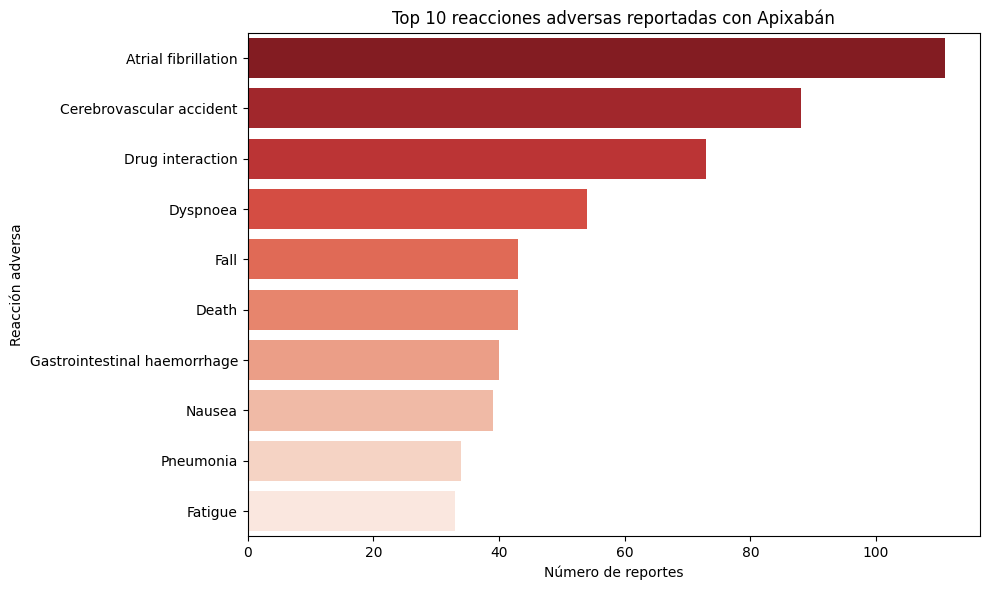

In [4]:
top_reacciones = df["reaccion"].value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_reacciones.values, y=top_reacciones.index, palette="Reds_r")
plt.title("Top 10 reacciones adversas reportadas con Apixabán")
plt.xlabel("Número de reportes")
plt.ylabel("Reacción adversa")
plt.tight_layout()
plt.savefig("top_reacciones.png", dpi=150)
plt.show()

Casos 'Grave' con edad válida: 2354
Casos 'No grave' con edad válida: 92
Edad promedio (Grave): 72.6
Edad promedio (No grave): 76.1

Estadístico U: 94869.5
Valor p: 0.04341136810017755

→ Hay diferencia estadísticamente significativa en la edad entre casos graves y no graves.


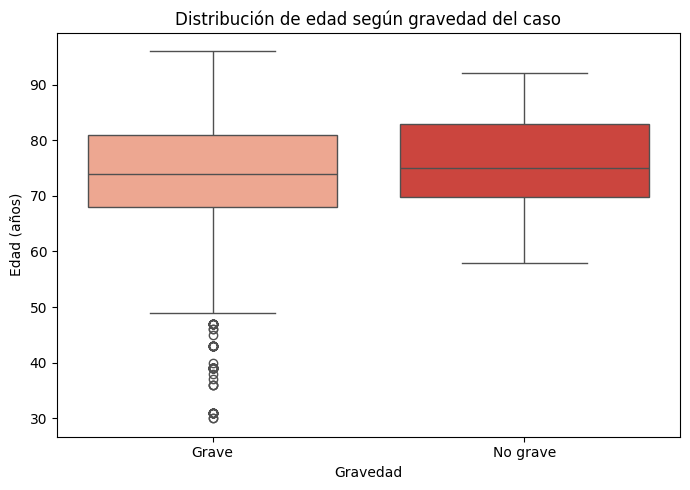

In [5]:
edad_grave = df[df["grave"] == "Grave"]["edad"].dropna()
edad_no_grave = df[df["grave"] == "No grave"]["edad"].dropna()

print("Casos 'Grave' con edad válida:", len(edad_grave))
print("Casos 'No grave' con edad válida:", len(edad_no_grave))
print("Edad promedio (Grave):", round(edad_grave.mean(), 1))
print("Edad promedio (No grave):", round(edad_no_grave.mean(), 1))

estadistico, p_valor = stats.mannwhitneyu(edad_grave, edad_no_grave, alternative="two-sided")
print("\nEstadístico U:", estadistico)
print("Valor p:", p_valor)

if p_valor < 0.05:
    print("\n→ Hay diferencia estadísticamente significativa en la edad entre casos graves y no graves.")
else:
    print("\n→ No hay diferencia estadísticamente significativa.")

plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="grave", y="edad", hue="grave", palette="Reds", legend=False)
plt.title("Distribución de edad según gravedad del caso")
plt.xlabel("Gravedad")
plt.ylabel("Edad (años)")
plt.tight_layout()
plt.savefig("edad_gravedad.png", dpi=150)
plt.show()